In [ ]:
!pip install gurobipy
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 40.0 MB/s eta 0:00:00


In [ ]:
# # Gurobi WLS license file
# # Your credentials are private and should not be shared or copied to public repositories.
# # Visit https://license.gurobi.com/manager/doc/overview for more information.
# WLSACCESSID=3912ee00-23d5-4dd5-974d-01c4b578f603
# WLSSECRET=d17125c9-d8ed-43bc-8bff-918c654858e1
# LICENSEID=

# Create an environment with your WLS license
params = {
"WLSACCESSID": '70dfc049-325a-4d24-aaa8-5ade8b89a83f',
"WLSSECRET": '0ec454be-1740-4518-b85c-c80e73fa2d34',
"LICENSEID":2729019,
}
env = gp.Env(params=params)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2729019
Academic license 2729019 - for non-commercial use only - registered to tr___@columbia.edu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Problem of Budgeting

In [ ]:
# 1. Load data from Excel

## From google drive; comment and run accordingly
data_path = "/content/drive/MyDrive/Bard High School/population_cleaned.xlsx"
data_path2 = "/content/drive/MyDrive/Bard High School/child_care_regulated_cleaned.xlsx"
data_path3 = "/content/drive/MyDrive/Bard High School/potential_locations_cleaned.xlsx"

## From local system
# data_path = "population_cleaned.xlsx"
# data_path2 = "child_care_regulated_cleaned.xlsx"
# data_path3 = "potential_locations_cleaned.xlsx"

# --- Sheet 1: population_cleaned.cleaned ---
pop_df = pd.read_excel(data_path, header=0, sheet_name="cleaned")

# --- Sheet 2a: child_care_regulated_cleaned.child_care_regulated ---
reg_df = pd.read_excel(data_path2, header=0, sheet_name="child_care_regulated")

# --- Sheet 2b: child_care_regulated_cleaned.build_facility ---
build_df = pd.read_excel(data_path2, header=0, sheet_name="build_facility")

# --- Sheet 3: potential_locations_cleaned.potential_locations_cleaned ---
new_loc_df = pd.read_excel(data_path3, header=0, sheet_name="potential_locations_cleaned")

pop_df['zipcode'] = pop_df['zipcode'].astype(str)
reg_df['zip_code'] = reg_df['zip_code'].astype(str)
build_df['zipcode'] = build_df['zipcode'].astype(str) if 'zipcode' in build_df.columns else None
new_loc_df['zipcode'] = new_loc_df['zipcode'].astype(str) if 'zipcode' in new_loc_df.columns else None

In [ ]:
# 2. Create parameter dictionaries

zipcodes = pop_df['zipcode'].astype(str).unique().tolist()
sizes = build_df['Size'].tolist()

# Total capacity by zipcode
required_total = pop_df.set_index('zipcode')['required slots'].fillna(0).to_dict()
required_0_5 = pop_df.set_index('zipcode')['required slots 5'].fillna(0).to_dict()
cap_total = pop_df.set_index('zipcode')['current_slots'].fillna(0).to_dict()
cap_0_5 = pop_df.set_index('zipcode')['current_slots_5'].fillna(0).to_dict()

# Facilities and their capacities
facilities = reg_df.groupby('zip_code')['facility_id'].apply(list).to_dict()
cap_fac = {(str(row.zip_code), row.facility_id): row.total_capacity for _, row in reg_df.iterrows()}

# Building options
build_cost = build_df.set_index('Size')['build_cost'].to_dict()
cap_build = build_df.set_index('Size')['capacity'].to_dict()
cap_build_0_5 = build_df.set_index('Size')['capacity_0_5'].to_dict()

In [ ]:
m2 = gp.Model()

# number of new facilities built of size s
n2 = m2.addVars(valid_Z, S, vtype=gp.GRB.INTEGER, name="n2")

# number of new youth slots by building
S2_y = m2.addVars(valid_Z, S, vtype=gp.GRB.INTEGER, name="S2_y")

# number of new general slots by expansion
X2_e = m2.addVars(F, vtype=gp.GRB.INTEGER, name="X2_e")

# number of new youth slots by expansion
e2_yf = m2.addVars(F, vtype=gp.GRB.INTEGER, name="e2_yf")

# Create build decision variables ONLY for locations with population data
location_to_zip = valid_final.set_index("location_id")["zipcode"].astype(str).to_dict()

# only include locations whose zipcodes have population data
valid_locations_list = [
    loc_id
    for loc_id in valid_final["location_id"].tolist()
    if location_to_zip[loc_id] in valid_Z
]
build_decision = m2.addVars(valid_locations_list, vtype=gp.GRB.BINARY, name="build")

# youth expansion slots is a subset of total expansion slots
m2.addConstrs((e2_yf[f] <= X2_e[f] for f in F), name="young_subset")

# new youth slots built can't exceed limits imposed by problem
m2.addConstrs(
    (S2_y[z, s] <= k_ys[s] * n2[z, s] for z in valid_Z for s in S),
    name="young_from_new_limit",
)

# link build decisions to capacity variables
for loc_id in valid_locations_list:
    zipcode = location_to_zip[loc_id]
    m2.addConstr(
        sum(n2[zipcode, s] for s in S) >= build_decision[loc_id],
        name=f"build_link_{loc_id}",
    )


for f in F:
    Cf = C_f[f]
    # new constraint for problem 2: maximum expansion is 20%, any higher will have diminishing returns
    m2.addConstr(X2_e[f] <= 0.2 * Cf, name=f"cap_{f}")

zip_to_facilities = (
    facility_data.astype({"zipcode": str, "facilityid": str})
    .groupby("zipcode")["facilityid"]
    .apply(list)
    .to_dict()
)

# same desert check
for z in valid_Z:
    # get facilities in a zip code
    facilities_in_z = zip_to_facilities.get(z, [])

    # add all new slots created in new facilities
    existing_expansions = sum(X2_e[f] for f in facilities_in_z)

    # sum new capacity from new facilities in this zip
    new_capacity = sum(n2[z, s] * k_s[s] for s in S)

    # check desert based on alpha_z values
    m2.addConstr(
        C_z[z] + existing_expansions + new_capacity >= alpha_z[z] * P_z[z],
        name=f"desert_total_{z}",
    )

    # same thing for youth capacities
    existing_young_expansions = sum(e2_yf[f] for f in facilities_in_z)
    new_young_capacity = sum(S2_y[z, s] for s in S)
    # update constraints
    young_cap_z = C_y[z] + existing_young_expansions + new_young_capacity
    m2.addConstr(young_cap_z >= alpha_y * P_y[z], name=f"desert_young_{z}")


# create new cost structure constraints
# binary variables associated with the tier
b = m2.addVars(F, [1, 2, 3], vtype=gp.GRB.BINARY, name="b")
costs = {1: 200, 2: 400, 3: 1000}

# add tiered variables so the objective function is linear (following the approach outlined in lecture notes 8, section 3.3)
X_tier = m2.addVars(F, [1, 2, 3], vtype=gp.GRB.CONTINUOUS, name="X_tier")

for f in F:
    Cf = C_f[f]

    # the sum of tiered expansion must equal total expansion
    m2.addConstr(X2_e[f] == X_tier[f, 1] + X_tier[f, 2] + X_tier[f, 3],
                 name=f"total_expansion_{f}")

    # each factory belongs to 1 tier
    m2.addConstr(b[f, 1] + b[f, 2] + b[f, 3] == 1, name=f"one_tier_{f}")

    # 0 < expand <= 10%
    m2.addConstr(X_tier[f, 1] <= 0.10 * Cf * b[f, 1])  # max 10% if Tier 1 active
    m2.addConstr(X_tier[f, 1] >= 0.00)  # min 0% if Tier 1 active

    # 10 < expand <= 15%
    m2.addConstr(X_tier[f, 2] <= 0.15 * Cf * b[f, 2])  # max 15% if Tier 2 active
    m2.addConstr(X_tier[f, 2] >= 0.10 * Cf * b[f, 2])  # min 10% if Tier 2 active

    # 15 < expand <= 20%
    m2.addConstr(X_tier[f, 3] <= 0.20 * Cf * b[f, 3])  # max 20% if Tier 3 active
    m2.addConstr(X_tier[f, 3] >= 0.15 * Cf * b[f, 3])  # min 15% if Tier 3 active


In [ ]:
# 7. Optimize

m.optimize()



Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2729019 - for non-commercial use only - registered to tr___@columbia.edu
Optimize a model with 69287 rows, 55059 columns and 154588 nonzeros
Model fingerprint: 0xdb86842e
Variable types: 35331 continuous, 19728 integer (15603 binary)
Coefficient statistics:
  Matrix range     [1e+00, 9e+02]
  Objective range  [1e+02, 2e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+03]
Found heuristic solution: objective 6.950107e+08
Presolve removed 68547 rows and 54318 columns
Presolve time: 3.50s
Presolved: 740 rows, 741 columns, 1973 nonzeros
Found heuristic solution: objective 4.528524e+08
Variable types: 493 continuous, 248 integer (245 binary)

Root relaxation: interrupted, 398 iterations, 0.00 seconds (0.00 work units)

    N

In [ ]:
# 8. Results

if m.status == GRB.OPTIMAL:
    print(f"\nTotal Cost: ${m.objVal:,.0f}")
    print("\nNew Facilities (y,v):")
    for i in zipcodes:
        for s in sizes:
            if y[i,s].x > 0 or v[i,s].x > 0:
                print(f"{i} - {s}: y={y[i,s].x:.0f}, v={v[i,s].x:.0f}")
    print("\nExpansions (x,u):")
    for i in facilities:
        for f in facilities[i]:
            if x[i,f].x > 0 or u[i,f].x > 0:
                print(f"{i}-{f}: x={x[i,f].x:.0f}, u={u[i,f].x:.0f}")


Total Cost: $452,852,402

New Facilities (y,v):
10001 - large: y=2, v=400
10002 - large: y=7, v=1400
10003 - large: y=5, v=960
10004 - medium: y=1, v=100
10004 - large: y=1, v=189
10005 - large: y=2, v=323
10006 - medium: y=1, v=71
10007 - large: y=2, v=400
10009 - large: y=6, v=1200
10010 - large: y=5, v=948
10011 - large: y=4, v=764
10012 - large: y=2, v=400
10013 - large: y=4, v=800
10014 - small: y=1, v=1
10014 - large: y=2, v=400
10016 - large: y=6, v=1199
10017 - large: y=1, v=129
10018 - large: y=1, v=161
10019 - large: y=4, v=733
10021 - large: y=6, v=1191
10022 - large: y=4, v=800
10023 - large: y=12, v=2365
10024 - large: y=14, v=2799
10025 - large: y=14, v=2800
10026 - large: y=7, v=1400
10027 - large: y=12, v=2400
10028 - large: y=6, v=1110
10029 - large: y=13, v=2600
10030 - large: y=6, v=1200
10031 - large: y=8, v=1573
10032 - medium: y=1, v=100
10032 - large: y=7, v=1392
10033 - large: y=11, v=2137
10034 - large: y=9, v=1743
10035 - large: y=8, v=1588
10036 - large: y=1

In [ ]:
import seaborn as sns

In [ ]:
def plot_cost_distribution(m, y, v, u, x, z, build_cost, cap_build, cap_fac, facilities, sizes, zipcodes):
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    # --- Building cost ---
    build_cost_value = sum(build_cost[s] * y[i, s].X + 100.0 * v[i, s].X
                           for i in zipcodes for s in sizes)

    # --- Expansion cost ---
    expand_cost_value = 0.0
    for i in facilities:
        for f in facilities[i]:
            cap_if = cap_fac[(str(i), f)]
            coef_x = max(-0.62 * cap_if + 650.0, 0.0)
            expand_cost_value += ((20000.0 + 200.0 * cap_if) * z[i, f].X +
                                   coef_x * x[i, f].X +
                                   100.0 * u[i, f].X)

    # --- Create a DataFrame for plotting ---
    df_costs = pd.DataFrame({
        "Category": ["Building", "Expansion"],
        "Cost": [build_cost_value, expand_cost_value]
    })

    # --- Unified color palette ---
    dark_blue_gray = "#3B5998"
    warm_gold = "#EAC435"
    pie_colors = [dark_blue_gray, warm_gold]

    # --- Plot pie chart ---
    plt.figure(figsize=(6, 6))
    plt.pie(df_costs["Cost"],
            labels=df_costs["Category"],
            autopct="%.1f%%",
            startangle=90,
            colors=pie_colors,
            textprops={"color": "black"})
    plt.title("Cost Distribution", fontsize=13, fontweight="bold")
    plt.show()

    # --- Plot bar chart ---
    plt.figure(figsize=(6, 4))
    sns.barplot(x="Category", y="Cost", data=df_costs, palette=[dark_blue_gray, dark_blue_gray])
    plt.title("Cost Breakdown", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return df_costs

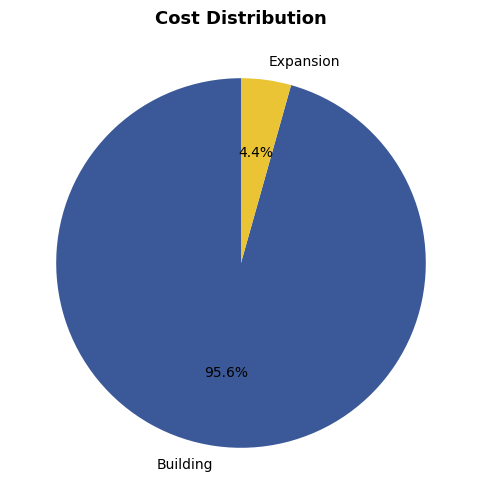

/tmp/ipython-input-2420984676.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="Cost", data=df_costs, palette=[dark_blue_gray, dark_blue_gray])


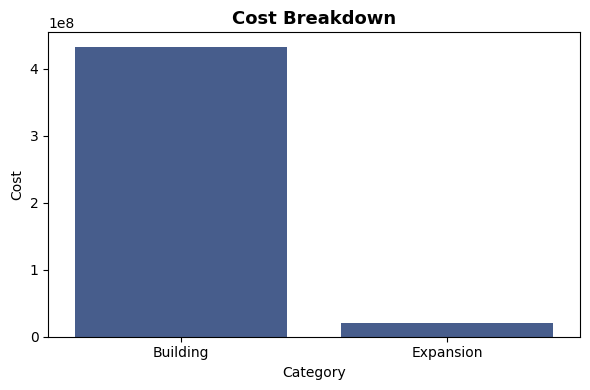

In [ ]:
df_costs = plot_cost_distribution(m, y, v, u, x, z, build_cost, cap_build, cap_fac, facilities, sizes, zipcodes)

In [ ]:

from matplotlib import rcParams

def plot_results_line(m, y, v, u, x, cap_total, cap_0_5, cap_build, facilities, sizes, zipcodes, step=50):
    """
    Visualize optimization results using line plots:
    Total capacity and 0–5 capacity by zipcode (full dataset shown).

    Parameters
    ----------
    m : gurobipy.Model
        Optimized Gurobi model.
    y, v, u, x : gurobipy tupledict
        Decision variables from the model.
    cap_total : dict
        Original total capacity per zipcode.
    cap_0_5 : dict
        Original 0–5 capacity per zipcode.
    cap_build : dict
        Capacity per facility size for new builds.
    facilities : dict
        Dictionary {zipcode: [facility1, facility2, ...]}.
    sizes : list
        Possible facility sizes for new builds.
    zipcodes : list
        List of zipcodes.
    step : int, default=50
        Interval for showing x-axis labels (e.g., show every 50th zipcode).
    """

    # --- Font fallback setup for Colab ---
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Georgia', 'serif']
    rcParams['axes.titlesize'] = 13
    rcParams['axes.labelsize'] = 12
    rcParams['xtick.labelsize'] = 10
    rcParams['ytick.labelsize'] = 10

    # --- Color palette ---
    dark_blue_gray = "#3B5998"
    warm_gold = "#EAC435"
    soft_green = "#88C999"
    palette = [dark_blue_gray, warm_gold, soft_green]
    sns.set_style("whitegrid")

    # --- Prepare data ---
    results = []
    for i in zipcodes:
        existing_total = cap_total.get(str(i), 0)
        existing_0_5 = cap_0_5.get(str(i), 0)

        new_total = sum(cap_build[s] * y[i, s].X for s in sizes)
        new_0_5 = sum(v[i, s].X for s in sizes)

        expanded_total = sum(x[i, f].X for f in facilities.get(i, []))
        expanded_0_5 = sum(u[i, f].X for f in facilities.get(i, []))

        results.append({
            "Zipcode": str(i),
            "Existing_Total": existing_total,
            "New_Total": new_total,
            "Expanded_Total": expanded_total,
            "Existing_0_5": existing_0_5,
            "New_0_5": new_0_5,
            "Expanded_0_5": expanded_0_5
        })

    df = pd.DataFrame(results)

    # --- Melt for plotting ---
    df_total = df.melt(id_vars="Zipcode",
                       value_vars=["Existing_Total", "New_Total", "Expanded_Total"],
                       var_name="Type", value_name="Capacity")
    df_0_5 = df.melt(id_vars="Zipcode",
                     value_vars=["Existing_0_5", "New_0_5", "Expanded_0_5"],
                     var_name="Type", value_name="Capacity_0_5")

    # --- Combined figure with two subplots ---
    fig, axes = plt.subplots(2, 1, figsize=(30, 10), sharex=True, dpi=150)

    # --- Top plot: Total Capacity ---
    sns.lineplot(ax=axes[0], x="Zipcode", y="Capacity", hue="Type",
                 data=df_total, palette=palette, linewidth=1.3)
    axes[0].set_title("Total Capacity by Zipcode", fontweight="bold")
    axes[0].set_ylabel("Total Capacity")
    axes[0].legend(title="Type", loc="upper right")

    # --- Bottom plot: 0–5 Capacity ---
    sns.lineplot(ax=axes[1], x="Zipcode", y="Capacity_0_5", hue="Type",
                 data=df_0_5, palette=palette, linewidth=1.3)
    axes[1].set_title("0–5 Capacity by Zipcode", fontweight="bold")
    axes[1].set_xlabel("Zipcode")
    axes[1].set_ylabel("0–5 Capacity")
    axes[1].legend(title="Type", loc="upper right")

    # --- X-axis label control (sparse display) ---
    xticks = range(0, len(df["Zipcode"]), step)
    axes[1].set_xticks(xticks)
    axes[1].set_xticklabels(df["Zipcode"].iloc[::step], rotation=45)

    plt.tight_layout()
    plt.show()

    return df

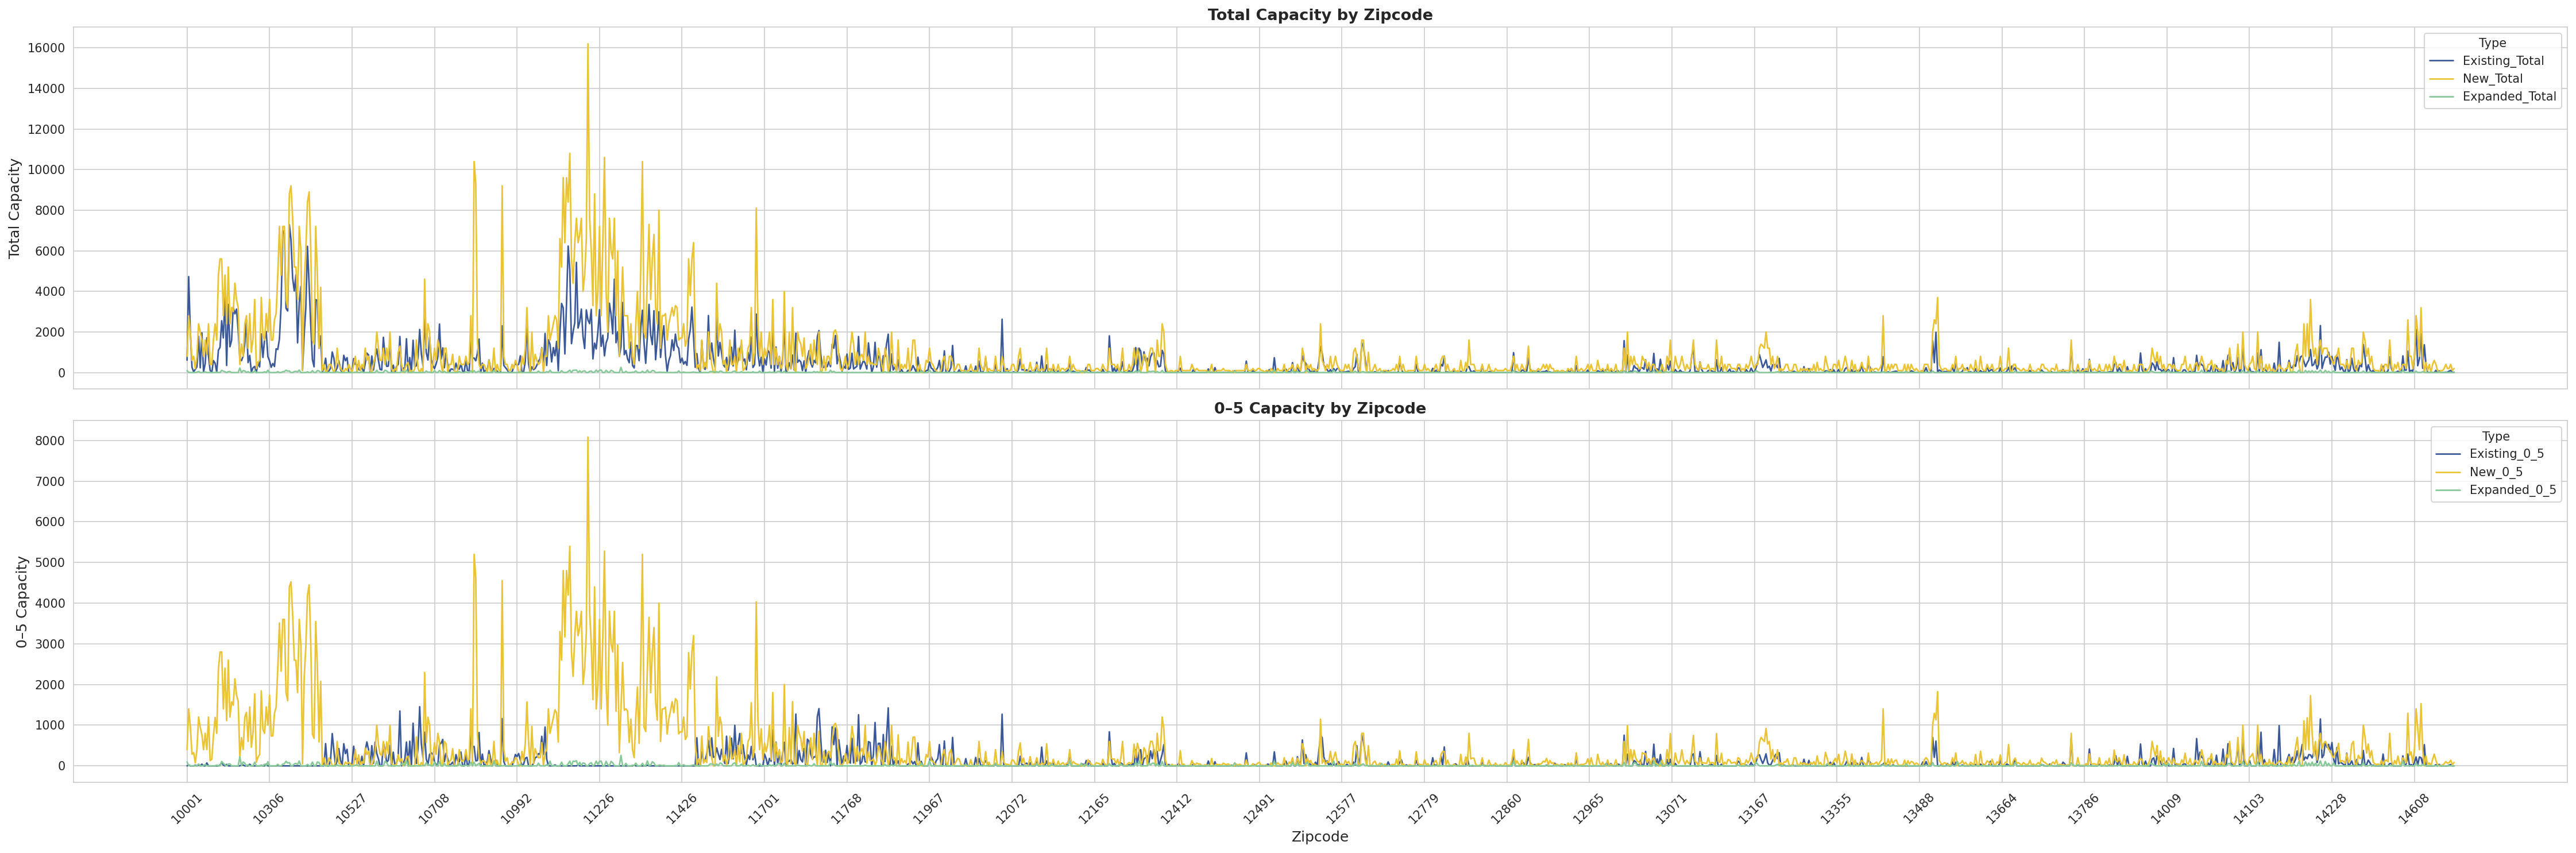

In [ ]:
df_results = plot_results_line(
    m, y, v, u, x,
    cap_total, cap_0_5, cap_build,
    facilities, sizes, zipcodes,
    step=50
)

# Problem of Realistic Capacity Expansion and Location

In [ ]:
def clean_coordinates(df):
    clean_df = df.copy()
    clean_df['latitude'] = pd.to_numeric(clean_df['latitude'], errors='coerce')
    clean_df['longitude'] = pd.to_numeric(clean_df['longitude'], errors='coerce')
    clean_df = clean_df.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)
    return clean_df

reg_clean = clean_coordinates(reg_df)

# Haversine function (distance in kilometers)
def haversine(lat1, lon1, lat2, lon2):
    """Compute great-circle distance between one point (lat1, lon1)
       and many points (lat2, lon2). Returns array of distances in km."""
    R = 6371.0  # Earth radius in kilometers

    # Convert all to radians
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    # Vectorized haversine
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c  # km

# Distance threshold (0.06 miles = 0.09656 km)
d_threshold = 0.09656

# Keep new facilities that are farther than threshold from all existing ones
valid_new_rows = []
for idx_new, new_row in new_loc_df.iterrows():
    distances = haversine(
        new_row['latitude'],
        new_row['longitude'],
        reg_clean['latitude'].values,
        reg_clean['longitude'].values
    )
    # Keep only if all distances ≥ threshold
    valid_new_rows.append(np.all(distances >= d_threshold))

# Build filtered dataset
valid_loc_phase1 = new_loc_df[valid_new_rows].reset_index(drop=True)

In [ ]:
valid_loc_phase1

,zipcode,latitude,longitude,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,0.09656
0,10307,40.498672,-74.250985,NaN,40.748836,-73.999810,NaN,40.752007,-74.005436,NaN,0.590697,1.0
1,10307,40.498923,-74.250320,NaN,40.748911,-74.001546,NaN,NaN,NaN,NaN,0.475278,1.0
2,10307,40.499100,-74.238473,NaN,40.752093,-74.002588,NaN,NaN,NaN,NaN,0.240091,1.0
3,10307,40.499563,-74.245183,NaN,40.748296,-74.001263,NaN,NaN,NaN,NaN,0.542073,1.0
4,10307,40.499845,-74.234653,NaN,40.749247,-74.001598,NaN,NaN,NaN,NaN,0.445768,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
131983,12979,44.997669,-73.367537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131984,12979,44.997673,-73.364635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131985,12979,44.997849,-73.368230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131986,12979,44.998012,-73.373017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
from scipy.spatial import cKDTree

# Earth's radius in kilometers
R = 6371.0
threshold_radians = d_threshold / R  # convert km to radians (for spherical coords)

# Step 1: Convert lat/lon to radians
valid_loc_phase1['lat_rad'] = np.radians(valid_loc_phase1['latitude'])
valid_loc_phase1['lon_rad'] = np.radians(valid_loc_phase1['longitude'])

# Step 2: Convert to 3D Cartesian coordinates on the unit sphere
lat = np.cos(valid_loc_phase1['lat_rad']) * np.cos(valid_loc_phase1['lon_rad'])
lon = np.cos(valid_loc_phase1['lat_rad']) * np.sin(valid_loc_phase1['lon_rad'])
z = np.sin(valid_loc_phase1['lat_rad'])
coords = np.vstack((lat, lon, z)).T

# Step 3: Build KD-tree
tree = cKDTree(coords)

# Step 4: Find all points within the threshold distance (in radians)
# Approximate chord length threshold on the unit sphere:
chord_thresh = 2 * np.sin(threshold_radians / 2)

# Keep track of which points to retain
n = len(valid_loc_phase1)
keep = np.ones(n, dtype=bool)

for i in range(n):
    if not keep[i]:
        continue  # skip if already marked for removal
    # Find neighbors within threshold
    idxs = tree.query_ball_point(coords[i], r=chord_thresh)
    idxs = [j for j in idxs if j > i]  # only consider later points
    keep[idxs] = False  # mark close neighbors for removal

valid_loc_final = valid_loc_phase1[keep].drop(columns=['lat_rad', 'lon_rad']).reset_index(drop=True)


In [ ]:
valid_loc_final


,zipcode,latitude,longitude,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,0.09656
0,10307,40.498672,-74.250985,NaN,40.748836,-73.999810,NaN,40.752007,-74.005436,NaN,0.590697,1.0
1,10307,40.499100,-74.238473,NaN,40.752093,-74.002588,NaN,NaN,NaN,NaN,0.240091,1.0
2,10307,40.499563,-74.245183,NaN,40.748296,-74.001263,NaN,NaN,NaN,NaN,0.542073,1.0
3,10307,40.499845,-74.234653,NaN,40.749247,-74.001598,NaN,NaN,NaN,NaN,0.445768,1.0
4,10307,40.500013,-74.253539,NaN,40.748836,-73.999810,NaN,NaN,NaN,NaN,0.590697,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
95311,12979,44.997230,-73.369198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95312,12979,44.997667,-73.368109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95313,12979,44.997673,-73.364635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95314,12979,44.998012,-73.373017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Problem 2: Modelling

In [ ]:
# 1. Potential-location variables

p = {}
locs_by_zip = {}
# adding (zipcode, potential_facility_id) as variable
for _, r in valid_loc_final.iterrows():
    z = str(r['zipcode'])
    loc_id = int(r.get('loc_id', r.name))
    p[(z, loc_id)] = m.addVar(vtype=GRB.BINARY, name=f"p_{z}_{loc_id}")
    locs_by_zip.setdefault(z, []).append(loc_id)

# enforcing M >= yis i.e # potential facilities per zip >= # of new facilities required per zip
for z in zipcodes:
    zs = str(z)
    lhs = gp.quicksum(p[(zs, l)] for l in locs_by_zip.get(zs, []))
    rhs = gp.quicksum(y[(zs, s)] for s in sizes)
    m.addConstr(lhs >= rhs, name=f"loc_link_{zs}")

In [ ]:
# 2. Expansion-tier indicators

alpha = {1: 200, 2: 400, 3: 1000}

I = {}
for z in facilities:
    for f in facilities[z]:
        capf = float(cap_fac[(str(z), f)])
        for k in [1, 2, 3]:
            I[(z, f, k)] = m.addVar(vtype=GRB.BINARY, name=f"I_{z}_{f}_{k}")
        m.addConstr(gp.quicksum(I[(z,f,k)] for k in [1,2,3]) <= 1,
                    name=f"one_interval_{z}_{f}")

        M = capf
        # interval bounds using big-M
        # Makes sure if facility is assigned small - holds maximum +10% expansion slots. Similarly for med and large
        m.addConstr(x[(z,f)] <= 0.10*capf + M*(1 - I[(z,f,1)]), name=f"xub1_{z}_{f}")
        m.addConstr(x[(z,f)] >= 0.00*capf - M*(1 - I[(z,f,1)]), name=f"xlb1_{z}_{f}")

        m.addConstr(x[(z,f)] <= 0.15*capf + M*(1 - I[(z,f,2)]), name=f"xub2_{z}_{f}")
        m.addConstr(x[(z,f)] >= 0.10*capf - M*(1 - I[(z,f,2)]), name=f"xlb2_{z}_{f}")

        m.addConstr(x[(z,f)] <= 0.20*capf + M*(1 - I[(z,f,3)]), name=f"xub3_{z}_{f}")
        m.addConstr(x[(z,f)] >= 0.15*capf - M*(1 - I[(z,f,3)]), name=f"xlb3_{z}_{f}")

In [ ]:
# # Print x dictionary values if the value is 0
# for key, var in x.items():
#     if var.x = 0:
#         print(f"{key}: {var.x}")

In [ ]:
# # Print x dictionary values if the value is 0
# for key, var in cap_fac.items():
#     if var == 0:
#         print(f"{key}: {var}")

In [ ]:
# 3. Objective Function

try:
    build_cost_expr
except NameError:
    build_cost_expr = gp.quicksum(
        build_cost[s]*y[i,s] + 100*v[i,s]
        for i in zipcodes for s in sizes
    )

expand_cost_expr = gp.quicksum(
    gp.quicksum(I[z,f,k] * (20000 / cap_fac[(str(z), f)] + alpha[k]) * x[z, f] for k in [1, 2, 3])
    + 100.0 * u[z, f]
    for (z, f) in u.keys() if (str(z), f) in cap_fac
)

m.setObjective(build_cost_expr + expand_cost_expr, GRB.MINIMIZE)

In [ ]:
# 4. Solve and display results

m.update()
m.optimize()

# if m.status == GRB.OPTIMAL:
#     print(f"\nOptimal total cost: ${m.objVal:,.0f}")

#     print("\n--- New facilities ---")
#     for z in zipcodes:
#         for s in sizes:
#             if y[z,s].X > 0.5:
#                 print(f"ZIP {z} size {s}: y={y[z,s].X:.0f}, v(0-5)={v[z,s].X:.0f}")

#     print("\n--- Potential locations chosen ---")
#     for (z,l), var in p.items():
#         if var.X > 0.5:
#             print(f"ZIP {z} – loc {l}")

#     print("\n--- Expansions ---")
#     for z in facilities:
#         for f in facilities[z]:
#             if x[z,f].X > 0.5:
#                 active_k = [k for k in [1,2,3] if I[z,f,k].X > 0.5]
#                 print(f"{z}-{f}: x={x[z,f].X:.1f}, u={u[z,f].X:.1f}, α={ [alpha[k] for k in active_k] }")
# else:
#     print("Model not optimal (status =", m.status, ")")


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2729019 - for non-commercial use only - registered to tr___@columbia.edu
Optimize a model with 179883 rows, 197184 columns and 488074 nonzeros
Model fingerprint: 0xf841dd70
Model has 46809 quadratic objective terms
Variable types: 35331 continuous, 161853 integer (157728 binary)
Coefficient statistics:
  Matrix range     [1e+00, 9e+02]
  Objective range  [1e+02, 1e+05]
  QObjective range [4e+02, 2e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+03]

MIP start from previous solve did not produce a new incumbent solution
MIP start from previous solve violates constraint loc_link_10452 by 3.000000000

Presolve removed 172838 rows and 176020 columns
Presolve time: 0.20s
Presolved: 7045 rows, 21164 columns, 31120 nonzeros
